In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plant1_gen = pd.read_csv('../data/Plant_1_Generation_Data.csv')
plant1_weather = pd.read_csv('../data/Plant_1_Weather_Sensor_Data.csv')

print(plant1_gen.shape)
print(plant1_gen.head())
print(plant1_gen.info())

(68778, 7)
          DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  \
0  15-05-2020 00:00   4135001  1BY6WEcLGh8j5v7       0.0       0.0   
1  15-05-2020 00:00   4135001  1IF53ai7Xc0U56Y       0.0       0.0   
2  15-05-2020 00:00   4135001  3PZuoBAID5Wc2HD       0.0       0.0   
3  15-05-2020 00:00   4135001  7JYdWkrLSPkdwr4       0.0       0.0   
4  15-05-2020 00:00   4135001  McdE0feGgRqW7Ca       0.0       0.0   

   DAILY_YIELD  TOTAL_YIELD  
0          0.0    6259559.0  
1          0.0    6183645.0  
2          0.0    6987759.0  
3          0.0    7602960.0  
4          0.0    7158964.0  
<class 'pandas.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  str    
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  str    
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float

In [2]:
print(plant1_weather.shape)
print(plant1_weather.head())
print(plant1_weather.info())

(3182, 6)
             DATE_TIME  PLANT_ID       SOURCE_KEY  AMBIENT_TEMPERATURE  \
0  2020-05-15 00:00:00   4135001  HmiyD2TTLFNqkNe            25.184316   
1  2020-05-15 00:15:00   4135001  HmiyD2TTLFNqkNe            25.084589   
2  2020-05-15 00:30:00   4135001  HmiyD2TTLFNqkNe            24.935753   
3  2020-05-15 00:45:00   4135001  HmiyD2TTLFNqkNe            24.846130   
4  2020-05-15 01:00:00   4135001  HmiyD2TTLFNqkNe            24.621525   

   MODULE_TEMPERATURE  IRRADIATION  
0           22.857507          0.0  
1           22.761668          0.0  
2           22.592306          0.0  
3           22.360852          0.0  
4           22.165423          0.0  
<class 'pandas.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE_TIME            3182 non-null   str    
 1   PLANT_ID             3182 non-null   int64  
 2   SOURCE_KEY           31

In [3]:
plant1_gen['DATE_TIME'] = pd.to_datetime(plant1_gen['DATE_TIME'], format='%d-%m-%Y %H:%M')
plant1_weather['DATE_TIME'] = pd.to_datetime(plant1_weather['DATE_TIME'])

df = pd.merge(plant1_gen, plant1_weather[['DATE_TIME', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']], on='DATE_TIME', how='left')

print(df.shape)
print(df.head())

(68778, 10)
   DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  DAILY_YIELD  \
0 2020-05-15   4135001  1BY6WEcLGh8j5v7       0.0       0.0          0.0   
1 2020-05-15   4135001  1IF53ai7Xc0U56Y       0.0       0.0          0.0   
2 2020-05-15   4135001  3PZuoBAID5Wc2HD       0.0       0.0          0.0   
3 2020-05-15   4135001  7JYdWkrLSPkdwr4       0.0       0.0          0.0   
4 2020-05-15   4135001  McdE0feGgRqW7Ca       0.0       0.0          0.0   

   TOTAL_YIELD  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION  
0    6259559.0            25.184316           22.857507          0.0  
1    6183645.0            25.184316           22.857507          0.0  
2    6987759.0            25.184316           22.857507          0.0  
3    7602960.0            25.184316           22.857507          0.0  
4    7158964.0            25.184316           22.857507          0.0  


In [4]:
print(df.isnull().sum())
print(df.describe())

DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
AMBIENT_TEMPERATURE    4
MODULE_TEMPERATURE     4
IRRADIATION            4
dtype: int64
                        DATE_TIME   PLANT_ID      DC_POWER      AC_POWER  \
count                       68778    68778.0  68778.000000  68778.000000   
mean   2020-06-01 08:02:49.458257  4135001.0   3147.426211    307.802752   
min           2020-05-15 00:00:00  4135001.0      0.000000      0.000000   
25%           2020-05-24 00:45:00  4135001.0      0.000000      0.000000   
50%           2020-06-01 14:30:00  4135001.0    429.000000     41.493750   
75%           2020-06-09 20:00:00  4135001.0   6366.964286    623.618750   
max           2020-06-17 23:45:00  4135001.0  14471.125000   1410.950000   
std                           NaN        0.0   4036.457169    394.396439   

        DAILY_YIELD   TOTAL_YIELD  AMBIENT_TEMPERATU

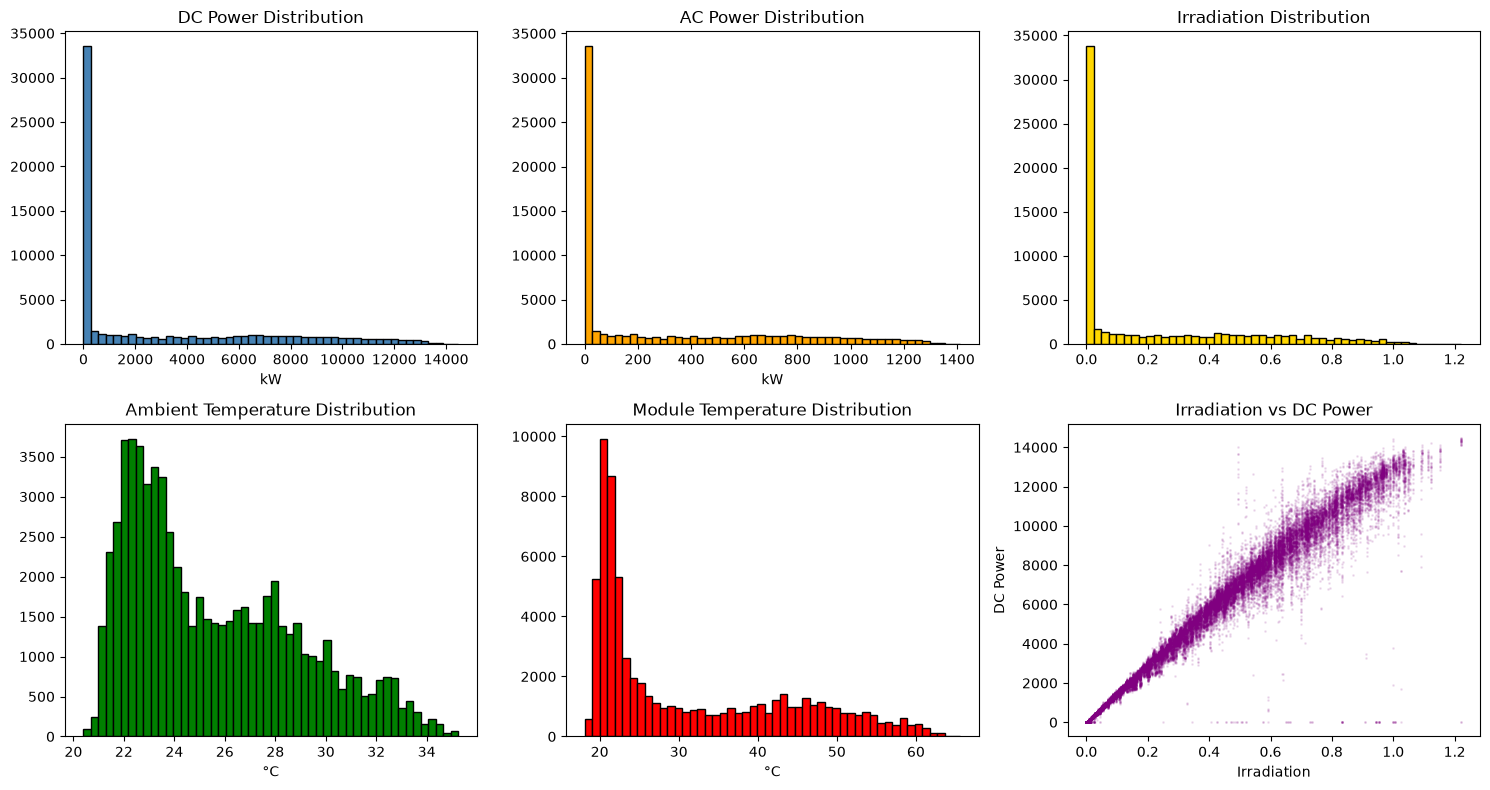

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].hist(df['DC_POWER'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_title('DC Power Distribution')
axes[0, 0].set_xlabel('kW')

axes[0, 1].hist(df['AC_POWER'], bins=50, color='orange', edgecolor='black')
axes[0, 1].set_title('AC Power Distribution')
axes[0, 1].set_xlabel('kW')

axes[0, 2].hist(df['IRRADIATION'], bins=50, color='gold', edgecolor='black')
axes[0, 2].set_title('Irradiation Distribution')

axes[1, 0].hist(df['AMBIENT_TEMPERATURE'].dropna(), bins=50, color='green', edgecolor='black')
axes[1, 0].set_title('Ambient Temperature Distribution')
axes[1, 0].set_xlabel('°C')

axes[1, 1].hist(df['MODULE_TEMPERATURE'].dropna(), bins=50, color='red', edgecolor='black')
axes[1, 1].set_title('Module Temperature Distribution')
axes[1, 1].set_xlabel('°C')

axes[1, 2].scatter(df['IRRADIATION'], df['DC_POWER'], alpha=0.1, color='purple', s=1)
axes[1, 2].set_title('Irradiation vs DC Power')
axes[1, 2].set_xlabel('Irradiation')
axes[1, 2].set_ylabel('DC Power')

plt.tight_layout()
plt.savefig('../data/eda_overview.png')
plt.show()

In [6]:
df['AMBIENT_TEMPERATURE'].fillna(df['AMBIENT_TEMPERATURE'].median(), inplace=True)
df['MODULE_TEMPERATURE'].fillna(df['MODULE_TEMPERATURE'].median(), inplace=True)
df['IRRADIATION'].fillna(df['IRRADIATION'].median(), inplace=True)

df['hour'] = df['DATE_TIME'].dt.hour
df['day'] = df['DATE_TIME'].dt.day
df['month'] = df['DATE_TIME'].dt.month

df['efficiency'] = df.apply(lambda x: x['AC_POWER'] / x['DC_POWER'] if x['DC_POWER'] > 0 else 0, axis=1)

print(df.isnull().sum())
print(df[['efficiency', 'hour', 'day', 'month']].head(10))

C:\Users\hp\AppData\Local\Temp\ipykernel_3332\4284286284.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['AMBIENT_TEMPERATURE'].fillna(df['AMBIENT_TEMPERATURE'].median(), inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_3332\4284286284.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series 

DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
AMBIENT_TEMPERATURE    4
MODULE_TEMPERATURE     4
IRRADIATION            4
hour                   0
day                    0
month                  0
efficiency             0
dtype: int64
   efficiency  hour  day  month
0         0.0     0   15      5
1         0.0     0   15      5
2         0.0     0   15      5
3         0.0     0   15      5
4         0.0     0   15      5
5         0.0     0   15      5
6         0.0     0   15      5
7         0.0     0   15      5
8         0.0     0   15      5
9         0.0     0   15      5


In [7]:
df['AMBIENT_TEMPERATURE'] = df['AMBIENT_TEMPERATURE'].fillna(df['AMBIENT_TEMPERATURE'].median())
df['MODULE_TEMPERATURE'] = df['MODULE_TEMPERATURE'].fillna(df['MODULE_TEMPERATURE'].median())
df['IRRADIATION'] = df['IRRADIATION'].fillna(df['IRRADIATION'].median())

print(df.isnull().sum())

DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
hour                   0
day                    0
month                  0
efficiency             0
dtype: int64


In [11]:
df.to_csv('../data/solar_data_clean.csv', index=False)
print(f"Clean dataset saved: {df.shape[0]} rows, {df.shape[1]} columns")

Clean dataset saved: 68778 rows, 14 columns


In [12]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

features = ['DC_POWER', 'AC_POWER', 'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'efficiency']

X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = IsolationForest(n_estimators=100, contamination=0.02, random_state=42)
model.fit(X_scaled)

df['anomaly_score'] = model.decision_function(X_scaled)
df['anomaly'] = model.predict(X_scaled)
df['anomaly'] = df['anomaly'].map({1: 0, -1: 1})

print(f"Anomalies detected: {df['anomaly'].sum()} ({df['anomaly'].mean()*100:.1f}%)")

Anomalies detected: 1376 (2.0%)


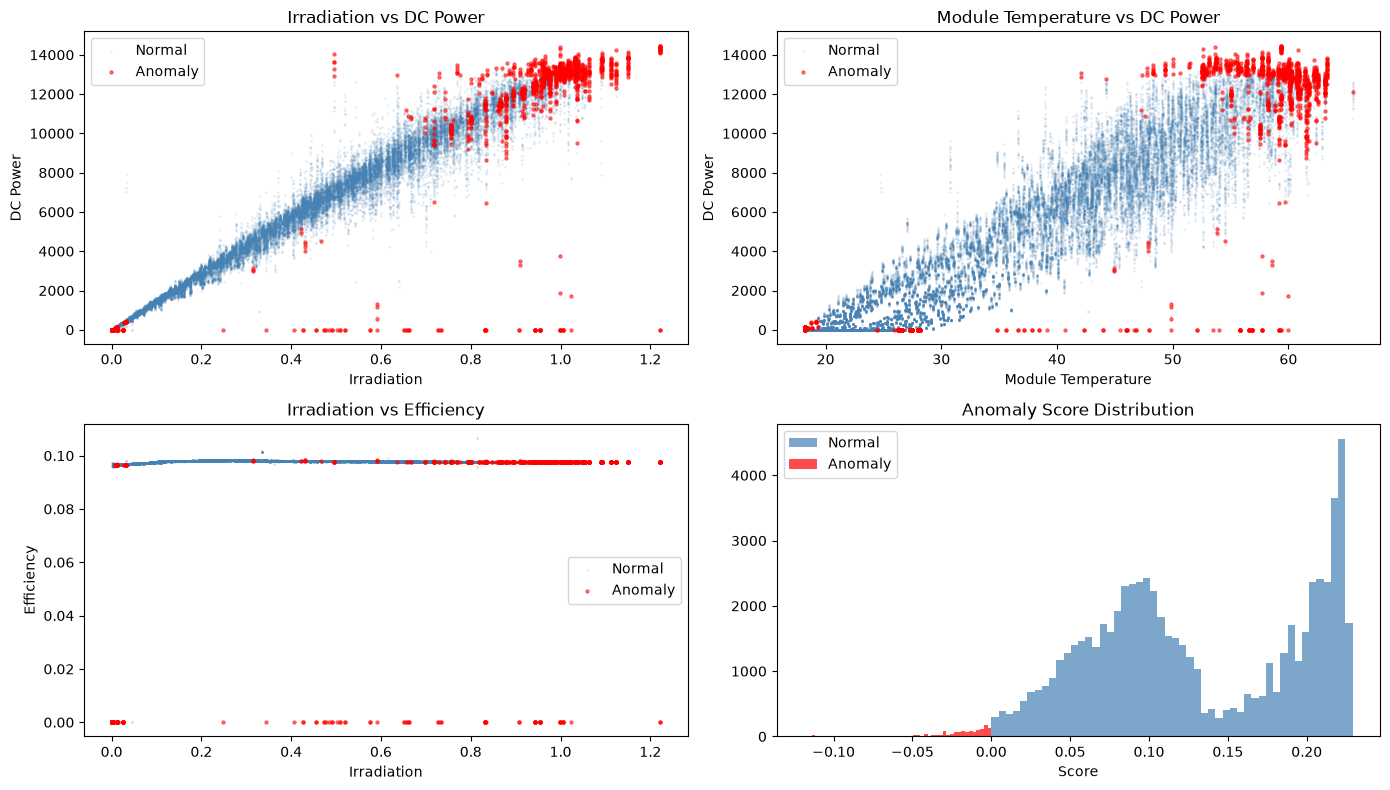

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

normal = df[df['anomaly'] == 0]
anomalies = df[df['anomaly'] == 1]

axes[0, 0].scatter(normal['IRRADIATION'], normal['DC_POWER'], alpha=0.1, s=1, color='steelblue', label='Normal')
axes[0, 0].scatter(anomalies['IRRADIATION'], anomalies['DC_POWER'], alpha=0.5, s=5, color='red', label='Anomaly')
axes[0, 0].set_title('Irradiation vs DC Power')
axes[0, 0].set_xlabel('Irradiation')
axes[0, 0].set_ylabel('DC Power')
axes[0, 0].legend()

axes[0, 1].scatter(normal['MODULE_TEMPERATURE'], normal['DC_POWER'], alpha=0.1, s=1, color='steelblue', label='Normal')
axes[0, 1].scatter(anomalies['MODULE_TEMPERATURE'], anomalies['DC_POWER'], alpha=0.5, s=5, color='red', label='Anomaly')
axes[0, 1].set_title('Module Temperature vs DC Power')
axes[0, 1].set_xlabel('Module Temperature')
axes[0, 1].set_ylabel('DC Power')
axes[0, 1].legend()

axes[1, 0].scatter(normal['IRRADIATION'], normal['efficiency'], alpha=0.1, s=1, color='steelblue', label='Normal')
axes[1, 0].scatter(anomalies['IRRADIATION'], anomalies['efficiency'], alpha=0.5, s=5, color='red', label='Anomaly')
axes[1, 0].set_title('Irradiation vs Efficiency')
axes[1, 0].set_xlabel('Irradiation')
axes[1, 0].set_ylabel('Efficiency')
axes[1, 0].legend()

axes[1, 1].hist(normal['anomaly_score'], bins=50, color='steelblue', alpha=0.7, label='Normal')
axes[1, 1].hist(anomalies['anomaly_score'], bins=50, color='red', alpha=0.7, label='Anomaly')
axes[1, 1].set_title('Anomaly Score Distribution')
axes[1, 1].set_xlabel('Score')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('../data/anomaly_detection.png')
plt.show()

In [14]:
import joblib

joblib.dump(model, '../models/isolation_forest.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("Model and scaler saved.")

Model and scaler saved.
